C:\Users\alarokia\AppData\Local\Temp\ipykernel_27228\1798988710.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


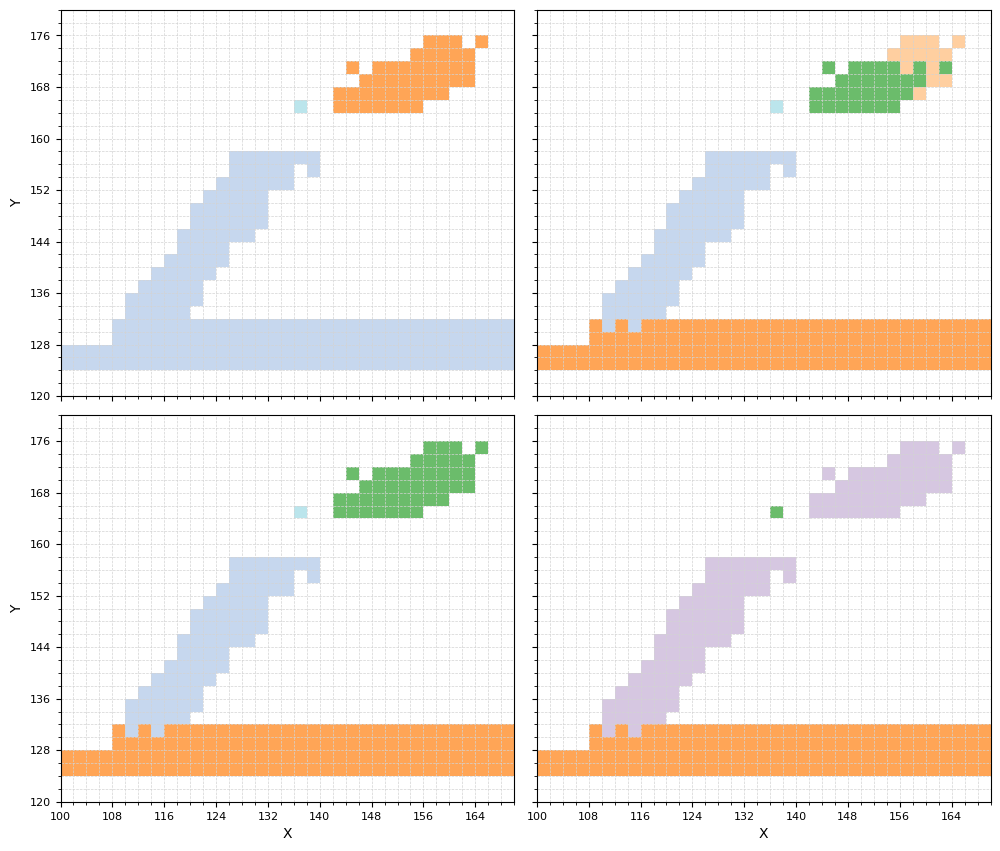

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import matplotlib.cm as cm

# Load the data
data = np.load('sim_10mev_3cm_event335.npy')

x = data[:, 0]
y = data[:, 1]

# Cluster labels
gmm_labels = data[:, 8]
db_labels  = data[:, 9]
pkl_labels = data[:, 10]
ckl_labels = data[:, 11]

label_dict = {
    "DB Clusters": db_labels,
    "GMM Clusters": gmm_labels,
    "PKL Labels": pkl_labels,
    "CKL Labels": ckl_labels
}

# Rectangle size
pixel_size_mm = 2

# Set axis limits manually
xlim = [100, 170]
ylim = [120, 180]

# Data aspect ratio (Y/X)
data_aspect = (ylim[1] - ylim[0]) / (xlim[1] - xlim[0])

# Subplot grid
nrows, ncols = 2, 2
subplot_width = 6
fig_width = ncols * subplot_width
fig_height = nrows * subplot_width * data_aspect

fig, axs = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height))
axs = axs.flatten()

# Colormap
cmap = cm.get_cmap('tab20')

# Function to add rectangles
def add_rectangles(ax, x, y, labels, cmap, pixel_size):
    for xi, yi, li in zip(x, y, labels):
        color = cmap(int(li) % cmap.N)
        rect = patches.Rectangle((xi, yi), pixel_size, pixel_size,
                                 linewidth=0.5, edgecolor='none', facecolor=color, alpha=0.7)
        ax.add_patch(rect)

# Function to set custom grid
def set_custom_grid(ax, x_limits, y_limits, pixel_size):
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    
    # Major ticks every 8 mm
    ax.set_xticks(np.arange(x_limits[0], x_limits[1]+1, 8))
    ax.set_yticks(np.arange(y_limits[0], y_limits[1]+1, 8))
    
    # Minor ticks every 1 mm
    ax.set_xticks(np.arange(x_limits[0], x_limits[1]+1, pixel_size), minor=True)
    ax.set_yticks(np.arange(y_limits[0], y_limits[1]+1, pixel_size), minor=True)
    
    # Draw grid for both minor and major
    ax.grid(which='both', color='lightgray', linestyle='--', linewidth=0.5)
    
    # Font size for ticks
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.tick_params(axis='both', which='minor', labelsize=6)

# Plot each cluster
for idx, (ax, labels) in enumerate(zip(axs, label_dict.values())):
    add_rectangles(ax, x, y, labels, cmap, pixel_size_mm)
    set_custom_grid(ax, x_limits=xlim, y_limits=ylim, pixel_size=pixel_size_mm)
    
    # Only show x-axis labels for bottom row
    if idx < ncols:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("X", fontsize=10)
    
    # Only show y-axis labels for left column
    if idx % ncols != 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel("Y", fontsize=10)

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()


In [7]:
data = np.load('sim_10mev_3cm_event335.npy')
# Function to find DBSCAN Clusters
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
from sklearn.cluster import DBSCAN
def dbcluster(data_array, N_PROC, nn_neighbor, nn_radius, db_min_samples, sensitivity_, eps_threshold_, eps_mode_):
    """
    Perform DBSCAN clustering on a given data array with adaptive epsilon calculation.

    Parameters:
    - data_array: np.ndarray
        Input data with at least 3 columns (x, y, z).
    - N_PROC: int
        Number of processes for parallel computation.
    - nn_neighbor: int
        Number of nearest neighbors for the NearestNeighbors algorithm.
    - nn_radius: float
        Radius for the NearestNeighbors algorithm.
    - db_min_samples: int
        Minimum samples for a cluster in DBSCAN.
    - sensitivity_: float
        Sensitivity for the KneeLocator.
    - eps_threshold_: float
        Threshold below which epsilon defaults to eps_mode_.
    - eps_mode_: float
        Default epsilon value if calculated epsilon is below threshold.

    Returns:
    - labels_: np.ndarray
        Cluster labels from DBSCAN or [-1, -1] in case of failure.
    - valid_cluster: bool
        True if clustering is successful, False otherwise.
    - epsilon_: float
        The epsilon value used for DBSCAN.
    """
    valid_cluster = True
    epsilon_ = 0  # Default epsilon value
    try:
        # Extract the first three columns (x, y, z)
        extractedData = data_array[:, 0:2 + 1]

        # Nearest neighbors setup
        neigh = NearestNeighbors(n_neighbors=nn_neighbor, radius=nn_radius)
        nbrs = neigh.fit(extractedData)
        distances, indices = nbrs.kneighbors(extractedData)
        distances = np.sort(distances, axis=0)
        dist_ = distances[:, nn_neighbor-1]
        # dist_ = distances[:, 1]

        # KneeLocator to find the optimal epsilon
        kneedle = KneeLocator(
            x = np.arange(len(dist_)),
            y=dist_,
            S=sensitivity_,
            curve='convex',
            direction='increasing',
            interp_method='interp1d'
        )
        if kneedle.knee is None:
            raise ValueError("KneeLocator failed to identify a knee point.")

        epsilon_ = round(dist_[int(kneedle.knee)], 2)
        if epsilon_ < eps_threshold_:
            print('EPSILON BELOW THRESHOLD, USING DEFAULT', eps_mode_, epsilon_)
            epsilon_ = eps_mode_
        else:
            print('USING EPSILON', epsilon_)
        # DBSCAN clustering
        model = DBSCAN(eps=epsilon_, min_samples=db_min_samples, n_jobs=N_PROC)
        labels_ = model.fit_predict(extractedData)
        return labels_, valid_cluster, epsilon_

    except ValueError as ve:
        print(f"ValueError: {ve}")
    except Exception as e:
        print(f"Error: {e}")

    # Return defaults in case of failure
    return np.array([-1, -1]), False, epsilon_

In [11]:
def plot_dbscan_results(data, labels_, dist_, kneedle, epsilon_):
    """
    Plot Kneedle curve (for epsilon detection) and 2D projections with DBSCAN labels.
    
    Parameters:
    - data: np.ndarray of shape (n_samples, 3)
    - labels_: cluster labels from DBSCAN
    - dist_: sorted nearest-neighbor distance array
    - kneedle: fitted KneeLocator object
    - epsilon_: epsilon chosen for DBSCAN
    """
    unique_labels = set(labels_)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    # --- Plot 1: Kneedle distance curve ---
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(np.arange(len(dist_)), dist_, marker=".", alpha=0.6)
    if kneedle.knee is not None:
        plt.axvline(kneedle.knee, color="r", linestyle="--", label=f"knee={kneedle.knee}")
        plt.axhline(epsilon_, color="g", linestyle="--", label=f"eps={epsilon_}")
    plt.title("Kneedle distance curve")
    plt.xlabel("Points sorted by distance")
    plt.ylabel("k-NN distance")
    plt.yscale('log')
    plt.ylim(0, 20)
    plt.legend()

    # --- Plot 2: 2D projection with DBSCAN clusters ---
    plt.subplot(1, 2, 2)
    for k, col in zip(unique_labels, colors):        
        # if k in [1, 2, 3, 4]:
        #     continue
        if k == -1:
            # Noise
            col = "k"
            size = 10
        else:
            size = 40
        xy = data[labels_ == k]
        print(k, len(xy[:, 0]))
        plt.scatter(xy[:, 0], xy[:, 1], c=[col], s=size, label=f"Cluster {k}" if k != -1 else "Noise", alpha=0.6)

    plt.title("DBSCAN clustering (2D projection)")
    plt.xlabel("X")
    plt.ylabel("Y")    
    plt.legend()
    plt.tight_layout()
    plt.show()

USING EPSILON 4.54
0 136
1 375
2 43
-1 2


C:\Users\alarokia\AppData\Local\Temp\ipykernel_27228\2681613790.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 20)


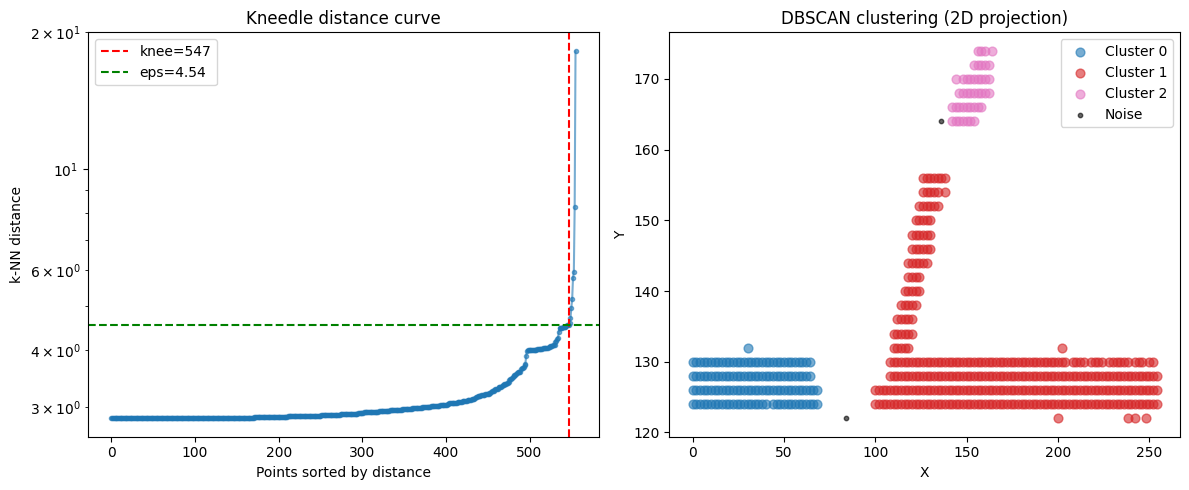

In [12]:
dbscan_labels, valid_cluster, epsilon_ = dbcluster(data,1,6,20,6,3,4,7)
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

neigh = NearestNeighbors(n_neighbors=6)
distances, _ = neigh.fit(data[:, :3]).kneighbors(data[:, :3])
distances = np.sort(distances, axis=0)
dist_ = distances[:, 5]

kneedle = KneeLocator(
    x=np.arange(len(dist_)),
    y=dist_,
    S=3,
    curve="convex",
    direction="increasing",
    interp_method='interp1d'
)

# Call plotting function
plot_dbscan_results(data, dbscan_labels, dist_, kneedle, epsilon_)

C:\Users\alarokia\AppData\Local\Temp\ipykernel_11316\331011038.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


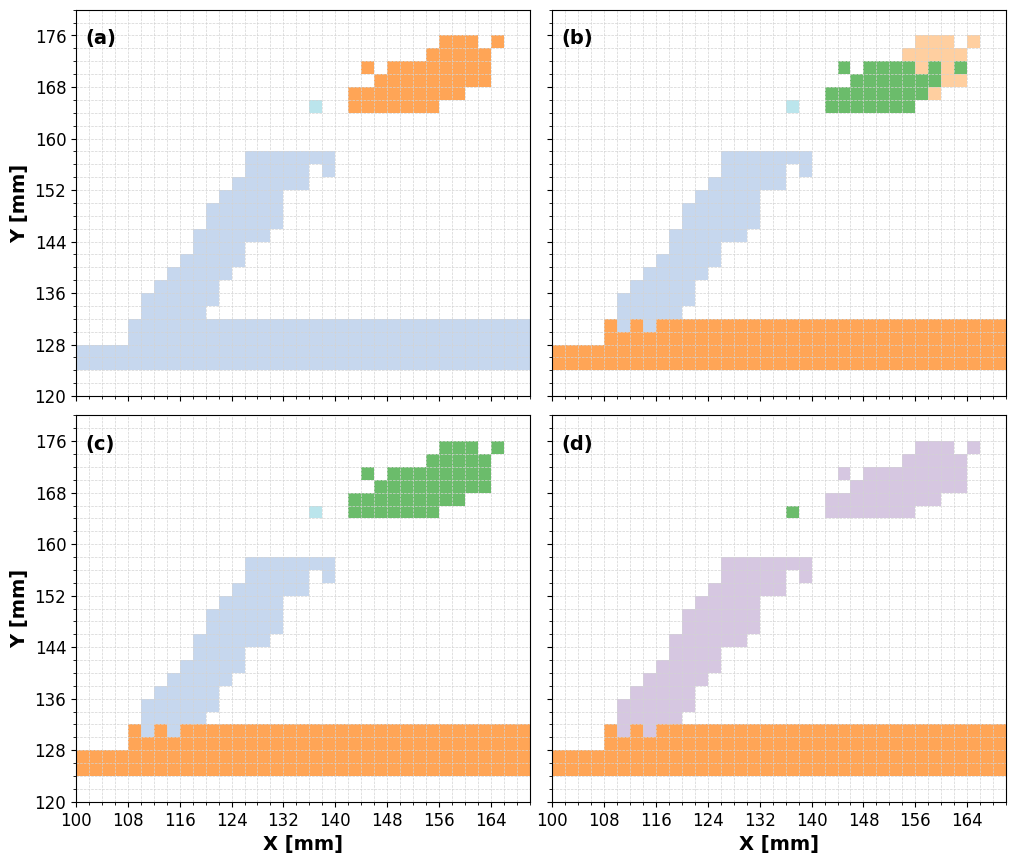

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import matplotlib.cm as cm

# Load the data
data = np.load('sim_10mev_3cm_event335.npy')

x = data[:, 0]
y = data[:, 1]

# Cluster labels
gmm_labels = data[:, 8]
db_labels  = data[:, 9]
pkl_labels = data[:, 10]
ckl_labels = data[:, 11]

label_dict = {
    "DB Clusters": db_labels,
    "GMM Clusters": gmm_labels,
    "PKL Labels": pkl_labels,
    "CKL Labels": ckl_labels
}

# Rectangle size
pixel_size_mm = 2

# Axis limits
xlim = [100, 170]
ylim = [120, 180]

# Data aspect ratio (Y/X)
data_aspect = (ylim[1] - ylim[0]) / (xlim[1] - xlim[0])

# Subplot grid
nrows, ncols = 2, 2
subplot_width = 6
fig_width = ncols * subplot_width
fig_height = nrows * subplot_width * data_aspect

fig, axs = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height))
axs = axs.flatten()

# Colormap
cmap = cm.get_cmap('tab20')

# Subplot labels
subplot_labels = ['(a)', '(b)', '(c)', '(d)']

# Function to add rectangles
def add_rectangles(ax, x, y, labels, cmap, pixel_size):
    for xi, yi, li in zip(x, y, labels):
        color = cmap(int(li) % cmap.N)
        rect = patches.Rectangle((xi, yi), pixel_size, pixel_size,
                                 linewidth=0.5, edgecolor='none', facecolor=color, alpha=0.7)
        ax.add_patch(rect)

# Function to set custom grid
def set_custom_grid(ax, x_limits, y_limits, pixel_size, tick_labelsize):
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    
    # Major ticks every 8 mm
    ax.set_xticks(np.arange(x_limits[0], x_limits[1]+1, 8))
    ax.set_yticks(np.arange(y_limits[0], y_limits[1]+1, 8))
    
    # Minor ticks every 1 mm
    ax.set_xticks(np.arange(x_limits[0], x_limits[1]+1, pixel_size), minor=True)
    ax.set_yticks(np.arange(y_limits[0], y_limits[1]+1, pixel_size), minor=True)
    
    # Draw grid for both minor and major
    ax.grid(which='both', color='lightgray', linestyle='--', linewidth=0.5)
    
    # Tick label size
    ax.tick_params(axis='both', which='major', labelsize=tick_labelsize)
    ax.tick_params(axis='both', which='minor', labelsize=int(tick_labelsize*0.8))

# Plot each cluster
axis_labelsize = 14  # font size for axis labels
tick_labelsize = 12  # font size for tick labels

for idx, (ax, labels) in enumerate(zip(axs, label_dict.values())):
    add_rectangles(ax, x, y, labels, cmap, pixel_size_mm)
    set_custom_grid(ax, x_limits=xlim, y_limits=ylim, pixel_size=pixel_size_mm,
                    tick_labelsize=tick_labelsize)
    
    # Only show x-axis labels for bottom row
    if idx < ncols:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("X [mm]", fontsize=axis_labelsize, fontweight='bold')
    
    # Only show y-axis labels for left column
    if idx % ncols != 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel("Y [mm]", fontsize=axis_labelsize, fontweight='bold')
    
    # Add subplot label (a), (b), etc.
    ax.text(0.02, 0.95, subplot_labels[idx], transform=ax.transAxes,
            fontsize=axis_labelsize, fontweight='bold', va='top', ha='left')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()


C:\Users\alarokia\AppData\Local\Temp\ipykernel_11316\639877105.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


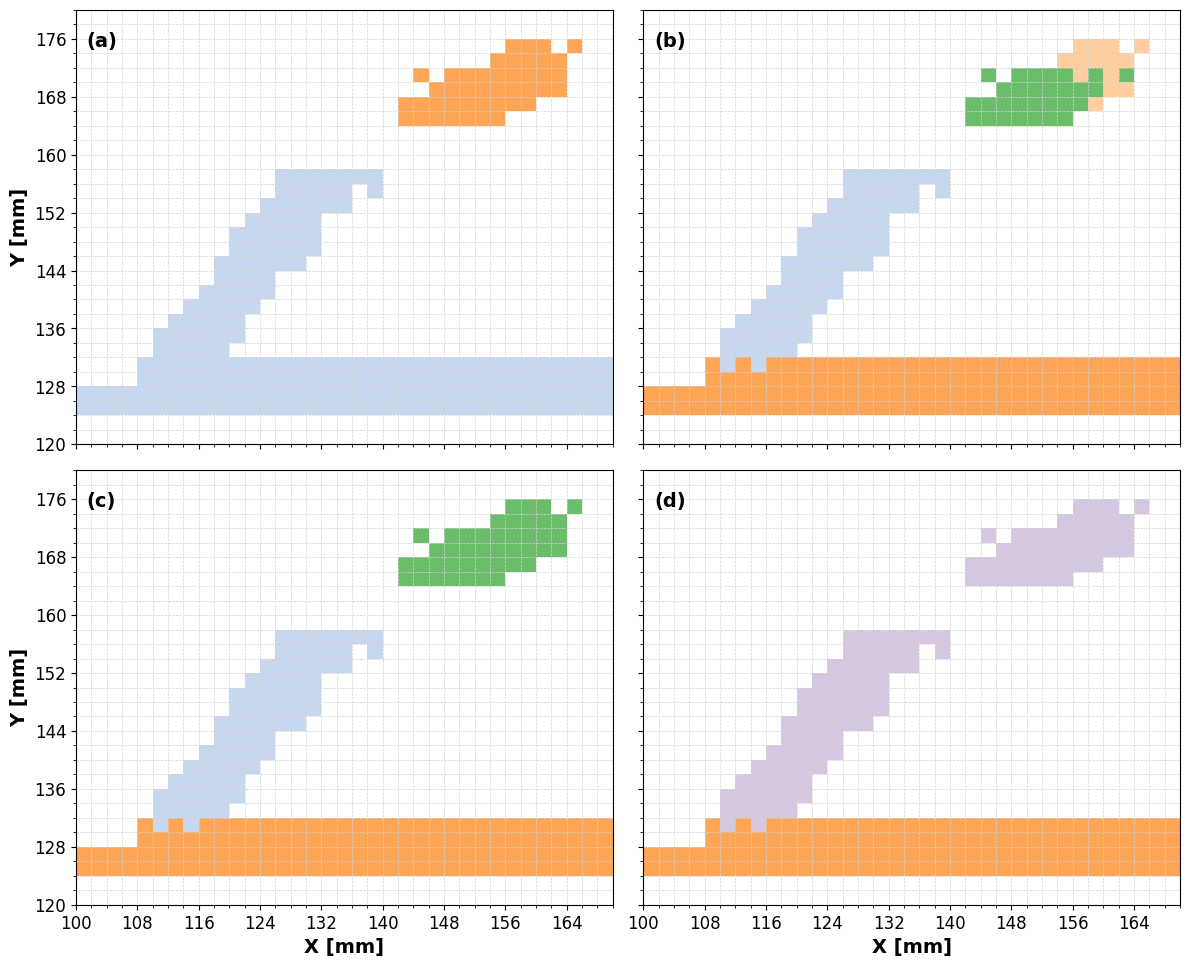

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import matplotlib.cm as cm

# Load the data
data = np.load('sim_10mev_3cm_event335.npy')

x = data[:, 0]
y = data[:, 1]

# Remove the point at X=136, Y=164
mask = ~((x == 136) & (y == 164))
x = x[mask]
y = y[mask]
data = data[mask, :]  # also mask all other columns to keep labels aligned

# Cluster labels
gmm_labels = data[:, 8]
db_labels  = data[:, 9]
pkl_labels = data[:, 10]
ckl_labels = data[:, 11]

label_dict = {
    "DB Clusters": db_labels,
    "GMM Clusters": gmm_labels,
    "PKL Labels": pkl_labels,
    "CKL Labels": ckl_labels
}

# Rectangle size = 2 mm
pixel_size_mm = 2

# Axis limits
xlim = [100, 170]
ylim = [120, 180]

# Data aspect ratio (Y/X)
data_aspect = (ylim[1] - ylim[0]) / (xlim[1] - xlim[0])

# Subplot grid
nrows, ncols = 2, 2
subplot_width = 6
fig_width = ncols * subplot_width
fig_height = nrows * subplot_width * data_aspect

fig, axs = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height))
axs = axs.flatten()

# Colormap
cmap = cm.get_cmap('tab20')

# Subplot labels
subplot_labels = ['(a)', '(b)', '(c)', '(d)']

# Function to add rectangles
def add_rectangles(ax, x, y, labels, cmap, pixel_size):
    for xi, yi, li in zip(x, y, labels):
        color = cmap(int(li) % cmap.N)
        rect = patches.Rectangle((xi, yi), pixel_size, pixel_size,
                                 linewidth=0.5, edgecolor='none', facecolor=color, alpha=0.7)
        ax.add_patch(rect)

# Function to set custom grid
def set_custom_grid(ax, x_limits, y_limits, pixel_size, tick_labelsize):
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    
    # Major ticks every 8 mm
    ax.set_xticks(np.arange(x_limits[0], x_limits[1]+1, 8))
    ax.set_yticks(np.arange(y_limits[0], y_limits[1]+1, 8))
    
    # Minor ticks every 1 mm
    ax.set_xticks(np.arange(x_limits[0], x_limits[1]+1, pixel_size), minor=True)
    ax.set_yticks(np.arange(y_limits[0], y_limits[1]+1, pixel_size), minor=True)
    
    # Draw grid for both minor and major
    ax.grid(which='both', color='lightgray', linestyle='--', linewidth=0.5)
    
    # Tick label size
    ax.tick_params(axis='both', which='major', labelsize=tick_labelsize)
    ax.tick_params(axis='both', which='minor', labelsize=int(tick_labelsize*0.8))

# Plot each cluster
axis_labelsize = 14  # font size for axis labels
tick_labelsize = 12  # font size for tick labels

for idx, (ax, labels) in enumerate(zip(axs, label_dict.values())):
    add_rectangles(ax, x, y, labels, cmap, pixel_size_mm)
    set_custom_grid(ax, x_limits=xlim, y_limits=ylim, pixel_size=pixel_size_mm,
                    tick_labelsize=tick_labelsize)
    
    # Only show x-axis labels for bottom row
    if idx < ncols:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("X [mm]", fontsize=axis_labelsize, fontweight='bold')
    
    # Only show y-axis labels for left column
    if idx % ncols != 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel("Y [mm]", fontsize=axis_labelsize, fontweight='bold')
    
    # Add subplot label (a), (b), etc.
    ax.text(0.02, 0.95, subplot_labels[idx], transform=ax.transAxes,
            fontsize=axis_labelsize, fontweight='bold', va='top', ha='left')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('cij.png', dpi=300, bbox_inches='tight')
plt.show()
